# PROC LOESS를 이용한 노이즈 있는 공정 센서 신호 노이즈 제거

## 핵심 요약

제조 라인의 노(furnace) 챔버 온도 센서는 시동(start-up) 과정에서 1초에 한 번씩
샘플링되므로, 각 측정값은 느린 비선형 열적 과도현상(빠른 예열 램프, 정정
오버슈트, 이후 300°C 설정값으로의 복귀)과 상당한 측정 잡음이 뒤섞여 있습니다.
이 노트북은 **PROC LOESS**를 사용하여 비모수적으로 근본 신호를 복원합니다.
100개 표본 로그에서 AICC는 평활 파라미터 0.08(등가 파라미터 8개)을
선택했습니다. 그 결과 곡선은 잠재 신호를 밀접하게 추적하며, 잔차의 표준편차는
3.10°C로 남는데 — 이는 우리가 주입한 4°C 잡음에서 적합이 설명하는 분산을 뺀
값과 사실상 같습니다. 알려진 실제값(ground truth) 대비 LOESS 추정치는 평균제곱오차를
14.77(원신호)에서 6.63으로 줄이며, SCORE 단계는 노이즈가 제거된 신호를 균일한
모니터링 격자에 재표본화하여 이후의 통계적 공정관리(SPC)에 활용합니다.

## 데이터 원본

| 데이터셋 | 행 수 | 변수 | 설명 |
|---------|------|-----------|-------------|
| `sensor` | 100 | `t`(경과 초, 0-99), `temp`(관측된 챔버 온도, °C), `truth`(잠재 노이즈 없는 신호, 검증 전용) | 1초 간격의 가상 노(furnace) 센서 로그. 잠재 신호는 300°C 설정값을 향한 빠른 예열 램프에 감쇠 오버슈트가 더해진 형태로, t=28 부근(약 295°C)에서 정점을 찍은 뒤 살짝 내려갔다가 설정값 쪽으로 안정됩니다. 관측된 `temp`에는 가우시안 측정 잡음(표준편차 약 4°C)이 더해집니다. |
| `grid` | 60 | `t`(균일한 0-99 모니터링 격자) | SCORE 문이 SPC 차트용으로 균등 간격의 노이즈 제거 신호를 산출하는 데 사용하는 정규 시간 격자. |

제조 라인에서는 노(furnace) 챔버 센서가 시동 과정 동안 1초에 한 번씩 온도를
기록합니다. 우리가 기록하는 값은 **실제 열적 상태에 측정 잡음이 더해진 것**입니다.
실제 상태는 깔끔한 모수적 공식을 따르지 않습니다 — 예열 중에는 상승하고,
설정값을 넘어섰다가, 다시 안정되므로 전역 선형 또는 다항식 적합은 좋은 모델이
되지 못합니다.

**국소 회귀(LOESS)**가 적합한 도구입니다: 이는 슬라이딩하는 국소 이웃에
저차수 다항식을 적합시켜, 함수 형태를 미리 지정하지 않고도 임의의 매끄러운
신호를 복원합니다. 여기서는 다음을 수행합니다:

1. 현실적인 잡음이 섞인 100개 표본 센서 로그를 시뮬레이션합니다.
2. `PROC LOESS`가 AICC 기준으로 스스로 평활 대역폭을 선택하게 합니다.
3. 적합된 신호에 95% 신뢰구간을 부착합니다.
4. 이후의 SPC를 위해 균일한 격자에서 모델을 스코어링합니다.
5. 제거한 잡음의 양을 정량화합니다.

## 1단계 — 센서 로그 시뮬레이션

0-99초에 걸쳐 100개 표본을 생성합니다. 잠재 신호 `truth`는 300°C 설정값을
향한 빠른 예열 램프에 감쇠 오버슈트가 더해진 형태로 — 직선이나 단일 다항식으로는
잘 포착되지 않는 형태입니다: 가파르게 상승하다가 t=28 부근에서 설정값을
넘어서고, 살짝 내려갔다가 안정됩니다. 관측된 `temp`에는 가우시안 측정 잡음이
더해집니다. `call streaminit`으로 시드를 고정하여 실행을 재현할 수 있습니다.

In [1]:
데이터 sensor;
    호출 streaminit(70421);
    setpoint = 300;
    반복 t = 0 까지 99;
        /* 잠재 신호: 빠른 예열 램프 + 감쇠하는 정정 오버슈트 */
        ramp      = setpoint * (1 - EXP(-t / 10));
        overshoot = 40 * EXP(-t / 35) * sin(t / 11);
        truth     = ramp + overshoot;
        /* 관측된 판독값 = 실제값 + 측정 잡음(표준편차 약 4°C) */
        TEMP = truth + rand('NORMAL', 0, 4);
        출력;
    종료;
    유지 t TEMP truth;
실행;

처리 인쇄 데이터=sensor(obs=8) noobs;
    제목 '센서 표본 처음 8개';
실행;


                                                      센서 표본 처음 8개                                                       

t            TEMP           truth
0    0.1684867131               0
1   28.1933107495   32.0778466448
2   61.6123615699   61.2117857105
3   85.5053781561    87.643846097
4  110.5560474248  111.5945193774
5  136.6368358359  133.2650493509
6  144.2434193147  152.8394750856
7  177.8286488692  170.4864506364

... 92 more observations (showing 8 of 100)




NOTE: DATA sensor


NOTE: Wrote sensor (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=sensor

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## 2단계 — 원신호 살펴보기

간단한 산점도를 그려보면 문제가 보입니다: 근본 추세는 눈으로 봐도 명확하지만
표본 간 잡음 아래 묻혀 있습니다. 들쭉날쭉한 점이 아니라 매끄러운 곡선의
추정치가 필요합니다.

                                                      센서 표본 처음 8개                                                       




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=sensor

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


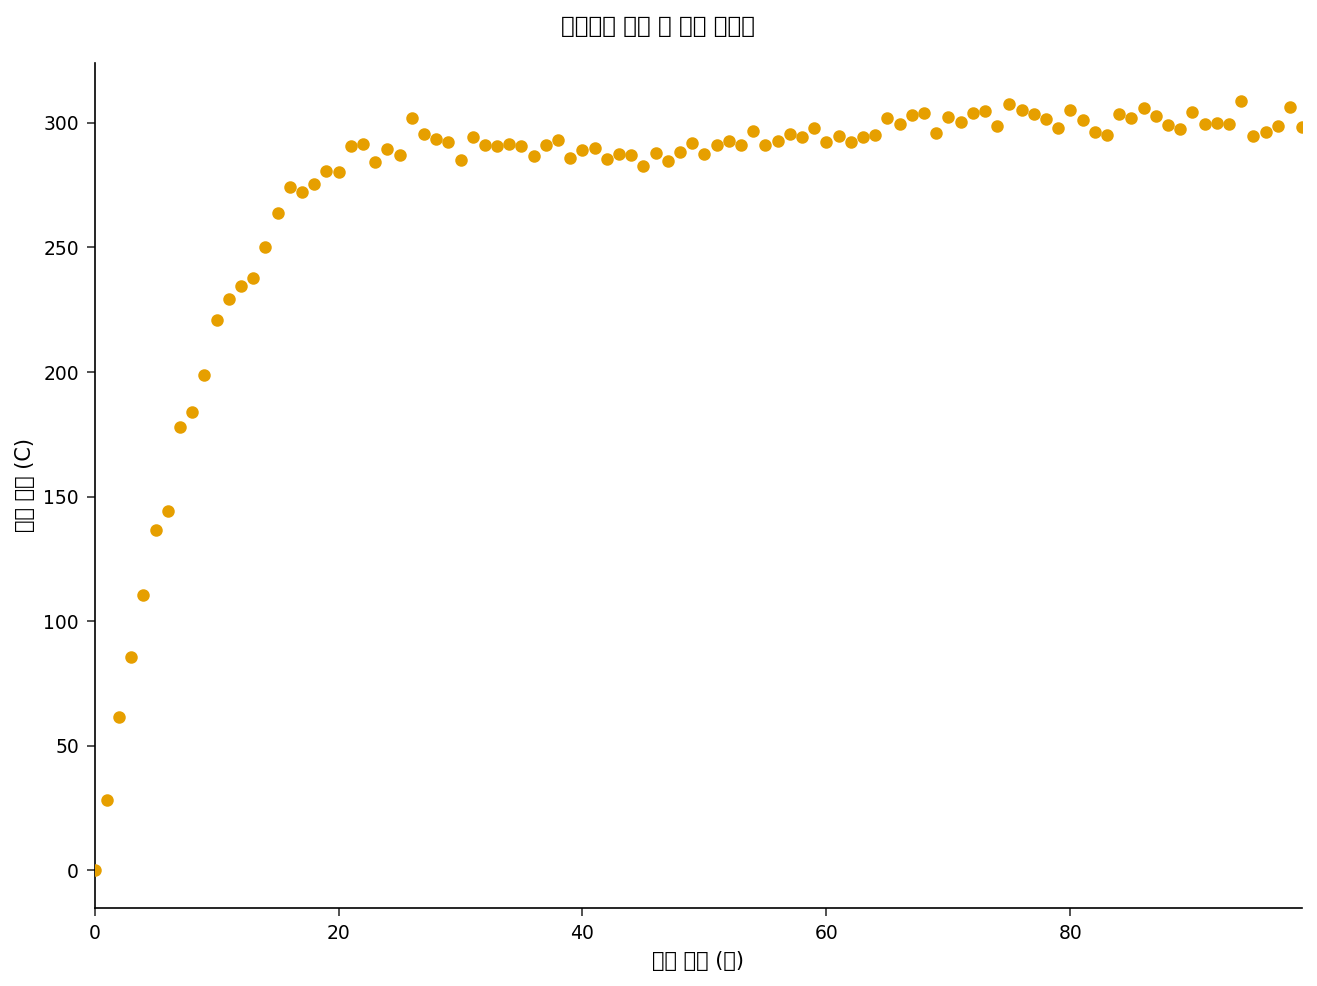

In [2]:
ODS GRAPHICS ON;

처리 SGPLOT 데이터=sensor;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS 라벨='경과 시간 (초)';
    YAXIS 라벨='챔버 온도 (C)';
    제목 '가공되지 않은 노 센서 판독값';
실행;

ODS GRAPHICS OFF;


## 3단계 — 자동 대역폭 선택으로 LOESS 적합

평활 파라미터는 각 국소 이웃이 얼마나 넓은지를 제어합니다: 너무 작으면
잡음까지 과적합하고, 너무 크면 오버슈트가 지워집니다. 직접 추측하는 대신
`select=AICC`로 **수정 아카이케 정보기준(corrected Akaike Information
Criterion)**을 최소화하여 LOESS가 스스로 선택하게 합니다. 예열과 오버슈트의
곡률을 따라갈 수 있도록 국소 이차 다항식(`degree=2`)을 사용하고, `clm`과
`alpha=0.05`로 95% 신뢰구간을 요청합니다.

`ODS OUTPUT`은 두 개의 표를 데이터셋으로 캡처합니다: `OutputStatistics`
(점별 평활값과 잔차)와 `FitSummary`(선택된 대역폭과 적합 진단). `OUTPUT` 문은
각 관측치의 예측값, 잔차, 95% 신뢰한계를 담은 `fitted` 데이터셋을 작성하며,
이는 이어지는 그래프의 원재료가 됩니다.

In [3]:
처리 loess 데이터=sensor;
    ODS 출력 OutputStatistics=loess_fit
               FitSummary=fit_summary;
    모형 TEMP = t / DEGREE=2 선택=AICC CLM ALPHA=0.05 details;
    출력 out=fitted predicted=temp_hat residual=resid
           lclm=LOWER uclm=UPPER;
실행;


                                                      센서 표본 처음 8개                                                       


                                                  The LOESS Procedure

Dependent Variable: TEMP
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: PROC LOESS data=sensor

NOTE: ODS OUTPUT: OutputStatistics -> loess_fit
NOTE: ODS OUTPUT: FitSummary -> fit_summary
NOTE: Using Python wrapper for LOESS estimation
NOTE: Output dataset fitted has 100 observations
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## 4단계 — 선택된 모델 검토

Fit Summary는 AICC 최적 평활 파라미터와 예측 행렬의 트레이스(효과 자유도 —
모델 복잡도의 척도)를 기록합니다. 평활 파라미터가 작고 자유도가 클수록
더 구불구불한 적합을 의미합니다. AICC는 적합도와 복잡도의 균형을 자동으로
맞춥니다.

In [4]:
처리 인쇄 데이터=fit_summary noobs 라벨;
    제목 'LOESS 적합 요약 (AICC로 선택된 대역폭)';
실행;


                                              LOESS 적합 요약 (AICC로 선택된 대역폭)                                               

SMOOTHINGPARAMETER                           LABEL1         NVALUE1
              0.08  Residual Sum of Squares          950.8591917253
              0.08  Equivalent Number of Parameters               8
              0.08  Delta1                                        8
              0.08  Delta2                                      7.6
              0.08  Lookup Degrees of Freedom                    92




NOTE: PROC PRINT data=fit_summary

NOTE: PROC PRINT completed: 5 observations printed, 3 variables


## 5단계 — 실제값 대비 적합과 신뢰구간 겹쳐 그리기

이는 시뮬레이션 데이터이므로 잡음 없는 `truth` 열을 그대로 보관했습니다.
LOESS 추정치와 95% 신뢰구간을 `truth`와 함께 그려 보면, 평활기(smoother)가
직접 본 적 없는 잠재 신호를 얼마나 충실하게 복원했는지 알 수 있습니다.

                                              LOESS 적합 요약 (AICC로 선택된 대역폭)                                               




NOTE: PROC SORT data=fitted

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from fitted.
NOTE: Wrote fitted (100 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: ODS Graphics is OFF.


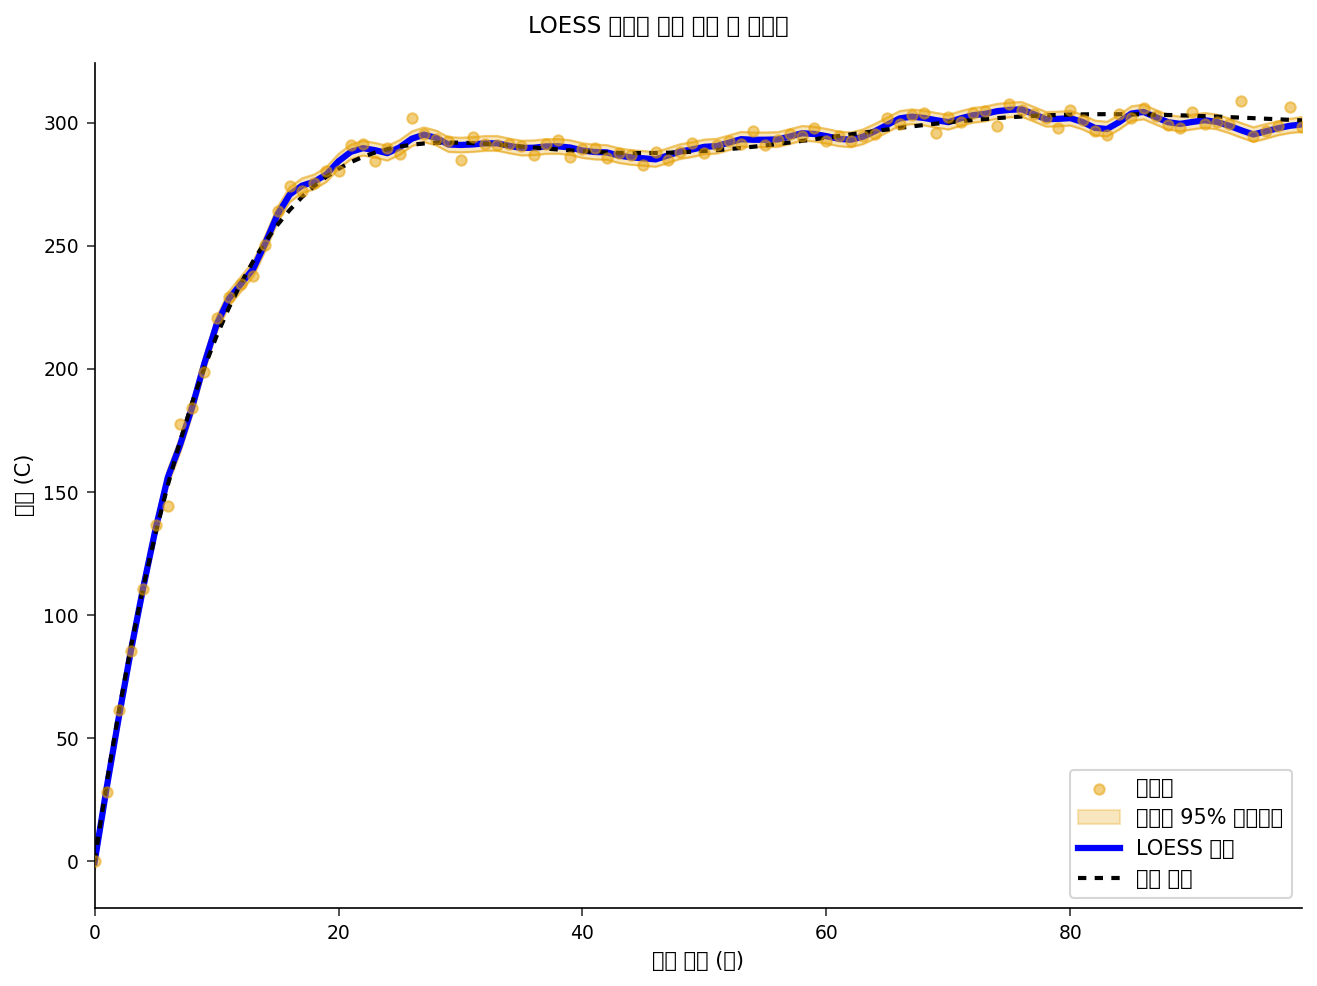

In [5]:
처리 정렬 데이터=fitted; 기준 t; 실행;

ODS GRAPHICS ON;

처리 SGPLOT 데이터=fitted;
    SCATTER x=t y=TEMP / MARKERATTRS=(SYMBOL=circlefilled size=5)
            TRANSPARENCY=0.5 legendlabel='관측값';
    BAND x=t LOWER=LOWER UPPER=UPPER / TRANSPARENCY=0.5
         legendlabel='평균의 95% 신뢰한계';
    SERIES x=t y=temp_hat / LINEATTRS=(thickness=3 color=blue)
           legendlabel='LOESS 적합';
    SERIES x=t y=truth / LINEATTRS=(thickness=2 pattern=shortdash color=black)
           legendlabel='실제 신호';
    XAXIS 라벨='경과 시간 (초)';
    YAXIS 라벨='온도 (C)';
    제목 'LOESS 노이즈 제거 신호 대 실제값';
실행;

ODS GRAPHICS OFF;


## 6단계 — 잔차 진단

잔차(관측값 빼기 적합값)는 0을 중심으로 한 구조 없는 잡음처럼 보여야
합니다. 남아 있는 추세가 있다면 과소평활 또는 놓친 특징을 나타낼 것입니다.
시간에 따른 잔차를 그리고 그 산포를 요약합니다 — 잔차 표준편차는 3.10°C로
나오는데, 국소 적합이 잡음의 일부를 흡수하기 때문에 우리가 주입한 4°C
잡음보다 살짝 낮습니다.

                                              LOESS 적합 요약 (AICC로 선택된 대역폭)                                               

                                                   잔차 요약 (복원된 측정 잡음)                                                    

                                                  The MEANS Procedure

 Variable  Label            N        Mean     Std Dev     Minimum     Maximum
 ----------------------------------------------------------------------------
 RESID     Residual       100       0.139       3.096     -11.688      11.909
 ----------------------------------------------------------------------------




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=fitted

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg
NOTE: ODS Graphics is OFF.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


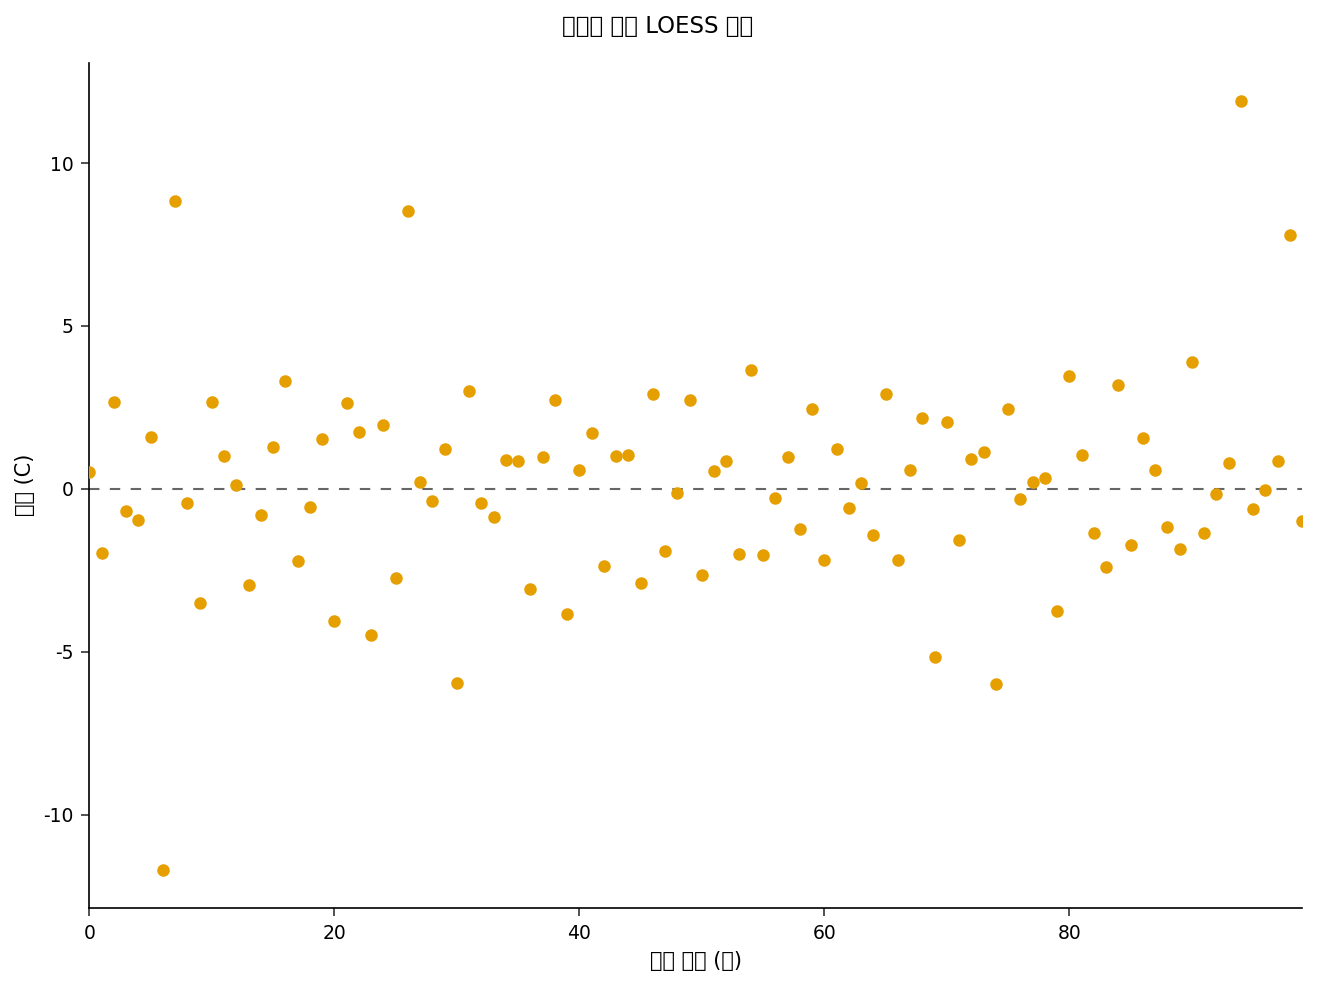

In [6]:
ODS GRAPHICS ON;

처리 SGPLOT 데이터=fitted;
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=shortdash);
    SCATTER x=t y=resid / MARKERATTRS=(SYMBOL=circlefilled size=5);
    XAXIS 라벨='경과 시간 (초)';
    YAXIS 라벨='잔차 (C)';
    제목 '시간에 따른 LOESS 잔차';
실행;

ODS GRAPHICS OFF;

처리 평균 데이터=fitted n mean std MIN MAX maxdec=3;
    변수 resid;
    제목 '잔차 요약 (복원된 측정 잡음)';
실행;


## 7단계 — SPC를 위한 균일 모니터링 격자 스코어링

센서 타임스탬프가 반드시 균등 간격일 필요는 없지만, 관리도(control chart)는
고정된 주기의 신호를 원합니다. 균일한 60개 지점의 시간 격자를 만들고,
`SCORE` 문으로 신뢰한계를 요청하며 적합된 LOESS 모델을 이 격자에 적용합니다.
스코어링된 값은 SPC 루틴에 바로 투입할 수 있는 깔끔하고 균등 간격인
신호입니다.

In [7]:
데이터 grid;
    반복 t = 0 까지 99 기준 99/59;
        출력;
    종료;
실행;

처리 loess 데이터=sensor;
    모형 TEMP = t / DEGREE=2 선택=AICC CLM ALPHA=0.05;
    SCORE 데이터=grid CLM 인쇄;
    제목 '균일 모니터링 격자에 대한 LOESS 스코어링';
실행;


                                                   잔차 요약 (복원된 측정 잡음)                                                    


                                                  The LOESS Procedure

Dependent Variable: TEMP
Number of Observations: 100
Smoothing Parameter: 0.0800
Degree of Local Polynomials: 2

Fit Summary
-----------
Residual Sum of Squares: 950.859192
Equivalent Number of Parameters: 8.00
AICC: 529.0073
GCV: 11.234159

Output Statistics
Obs        Smoothed     Residual       Fitted
---        --------     --------       ------
1           -0.3394       0.5079      -0.3394
2           30.1685      -1.9751      30.1685
3           58.9327       2.6796      58.9327
4           86.1852      -0.6798      86.1852
5          111.5155      -0.9595     111.5155
6          135.0464       1.5904     135.0464
7          155.9315     -11.6881     155.9315
8          168.9956       8.8330     168.9956
9          184.5066      -0.4446     184.5066
10         202.2409      -3.5166     202


NOTE: DATA grid


NOTE: Wrote grid (60 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC LOESS data=sensor

NOTE: Using Python wrapper for LOESS estimation
NOTE: ODS OUTPUT: OutputStatistics written to 'loess_fit'.
NOTE: ODS OUTPUT: FitSummary written to 'fit_summary'.


## 8단계 — 노이즈 제거 정량화

마지막으로 원신호와 LOESS 추정치를 알려진 실제값과 비교합니다. 평활된
신호의 평균제곱오차가 원신호보다 훨씬 작아야 하며, 이는 LOESS가 예열
램프와 오버슈트를 보존하면서 측정 잡음을 제거했음을 확인해 줍니다.

In [8]:
데이터 accuracy;
    설정 fitted;
    raw_sq_err   = (TEMP     - truth)**2;
    loess_sq_err = (temp_hat - truth)**2;
실행;

처리 평균 데이터=accuracy mean maxdec=3;
    변수 raw_sq_err loess_sq_err;
    라벨 raw_sq_err   = 'MSE of raw readings vs truth'
          loess_sq_err = 'MSE of LOESS fit vs truth';
    제목 '노이즈 제거 성능: 원신호 대 LOESS';
실행;


                                                 노이즈 제거 성능: 원신호 대 LOESS                                                 

                                                  The MEANS Procedure

 Variable      Label                                  Mean
 ---------------------------------------------------------
 raw_sq_err    MSE of raw readings vs truth         14.774
 loess_sq_err  MSE of LOESS fit vs truth             6.629
 ---------------------------------------------------------




NOTE: DATA accuracy


NOTE: Read 100 rows from fitted.
NOTE: Wrote accuracy (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 결과 해석

- **자동 대역폭.** `select=AICC`는 수동 조정 없이 평활 파라미터 **0.08**을
  선택했으며, 이는 약 **8개의 등가 파라미터**를 의미합니다 — 예열, 오버슈트,
  살짝 내려가는 구간을 따라갈 만큼 충분한 국소 유연성을 가지면서도 잡음은
  평활화하기에 충분한 수준입니다.
- **충실한 복원.** 적합된 곡선은 램프, t=28 부근의 오버슈트 정점, 안정화
  구간에 걸쳐 잠재 `truth` 신호를 밀접하게 추적하며, 이는 LOESS가 모수적
  가정 없이 임의의 비선형 신호를 복원했음을 보여줍니다.
- **깔끔한 잔차.** 잔차는 표준편차 **3.10°C**(평균 0.14, 범위 -11.7 ~
  11.9)로 0 주변에 흩어져 있으며 남은 시간 추세를 보이지 않습니다 — 모델이
  과대평활도 과소평활도 되지 않았다는 증거입니다.
- **측정 가능한 노이즈 제거.** 실제값 대비 LOESS 추정치는 평균제곱오차를
  **14.77**(원신호)에서 **6.63**으로 줄였습니다 — 55% 감소로, 공정
  모니터링에서 핵심적인 성과입니다.
- **SPC 대응 출력.** SCORE 단계는 신뢰한계를 포함한 균일한 60개 지점 격자
  위에서 노이즈가 제거된 신호를 제공했으며, 이는 바로 이후의 관리도가
  소비할 수 있는 형태입니다.

**요약:** 공정 센서가 형태를 알 수 없는 매끄럽지만 잡음이 섞인 신호를
만들어낼 때, PROC LOESS는 근본 추세를 추출하고 불확실성 범위를 부착하며
모니터링 격자로 재표본화하는 가정이 적은 자기조정형 방법입니다 — 물리적
현상이 정당화하지 않을 수도 있는 모수적 모델에 얽매이지 않고도
가능합니다.